<center> <h2><b>Machine Learning for Healthcare, Project 1: Time-Series</b></h2> </center>
<h3><b>Intensive Care Time Series Modeling for Mortality Predictions on 
the Physionet 2012 Challenge Dataset </b></h3>

In [1]:
import importlib
import sys
sys.path.append("..")  # Ensure the parent directory is in the path

from data_parsing.data_parsing import parse_data, extract_labels
import visualization.data_exploration_plots
import data_preprocessing.data_preprocessing

# Reload the module to reflect changes
importlib.reload(visualization.data_exploration_plots)
importlib.reload(data_preprocessing.data_preprocessing)

from visualization.data_exploration_plots import *
from data_preprocessing.data_cleaning import *
from data_preprocessing.data_preprocessing import *

from sklearn.preprocessing import StandardScaler

### **1. Data Processing and Exploration (5 Pts)**
#### Q1.1: Data Transformation (1 Pts)

In [2]:
# For the notebook to run, we suppose the data is inside a 'data' folder
dataset_paths = ['data/set-a', 'data/set-b', 'data/set-c']
outcome_paths = ['data/Outcomes-a.txt', 'data/Outcomes-b.txt', 'data/Outcomes-c.txt']

# Only need to run once
# for dataset in dataset_paths:
#     parse_data(dataset)

# for outcome in outcome_paths:
#     extract_labels(outcome)

# Read the parsed data saved as parquet files
X_set_a, X_set_b, X_set_c = pd.read_parquet('set-a.parquet'), pd.read_parquet('set-b.parquet'), pd.read_parquet('set-c.parquet')
Y_set_a, Y_set_b, Y_set_c = pd.read_parquet('outcomes-a.parquet'), pd.read_parquet('outcomes-b.parquet'), pd.read_parquet('outcomes-c.parquet')

# From X_set_c drop unnamed parameter column
X_set_c = X_set_c.drop(columns='')

print(X_set_a.shape, X_set_b.shape, X_set_c.shape)
print(Y_set_a.shape, Y_set_b.shape, Y_set_c.shape)

(196000, 43) (196000, 43) (196000, 43)
(4000, 2) (4000, 2) (4000, 2)


In [3]:
X_set_a.head(3)

,recordid,time,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,00:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132539,01:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
2,132539,02:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN


In [4]:
X_set_a[X_set_a["recordid"] == 132539]

,recordid,time,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,00:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132539,01:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
2,132539,02:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN
3,132539,03:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN
4,132539,04:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,20.0,NaN,NaN,37.8,NaN,NaN,60.0,NaN,NaN,NaN
5,132539,05:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,132539,06:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,17.0,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN
7,132539,07:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,132539,08:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,15.0,NaN,NaN,38.1,NaN,NaN,120.0,NaN,NaN,NaN
9,132539,09:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,14.0,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,NaN


In [5]:
Y_set_a.head(3)

,recordid,in_hospital_death
0,132539,0
1,132540,0
2,132541,0


#### Q1.2 Exploratory Data Analysis (2 Pts)

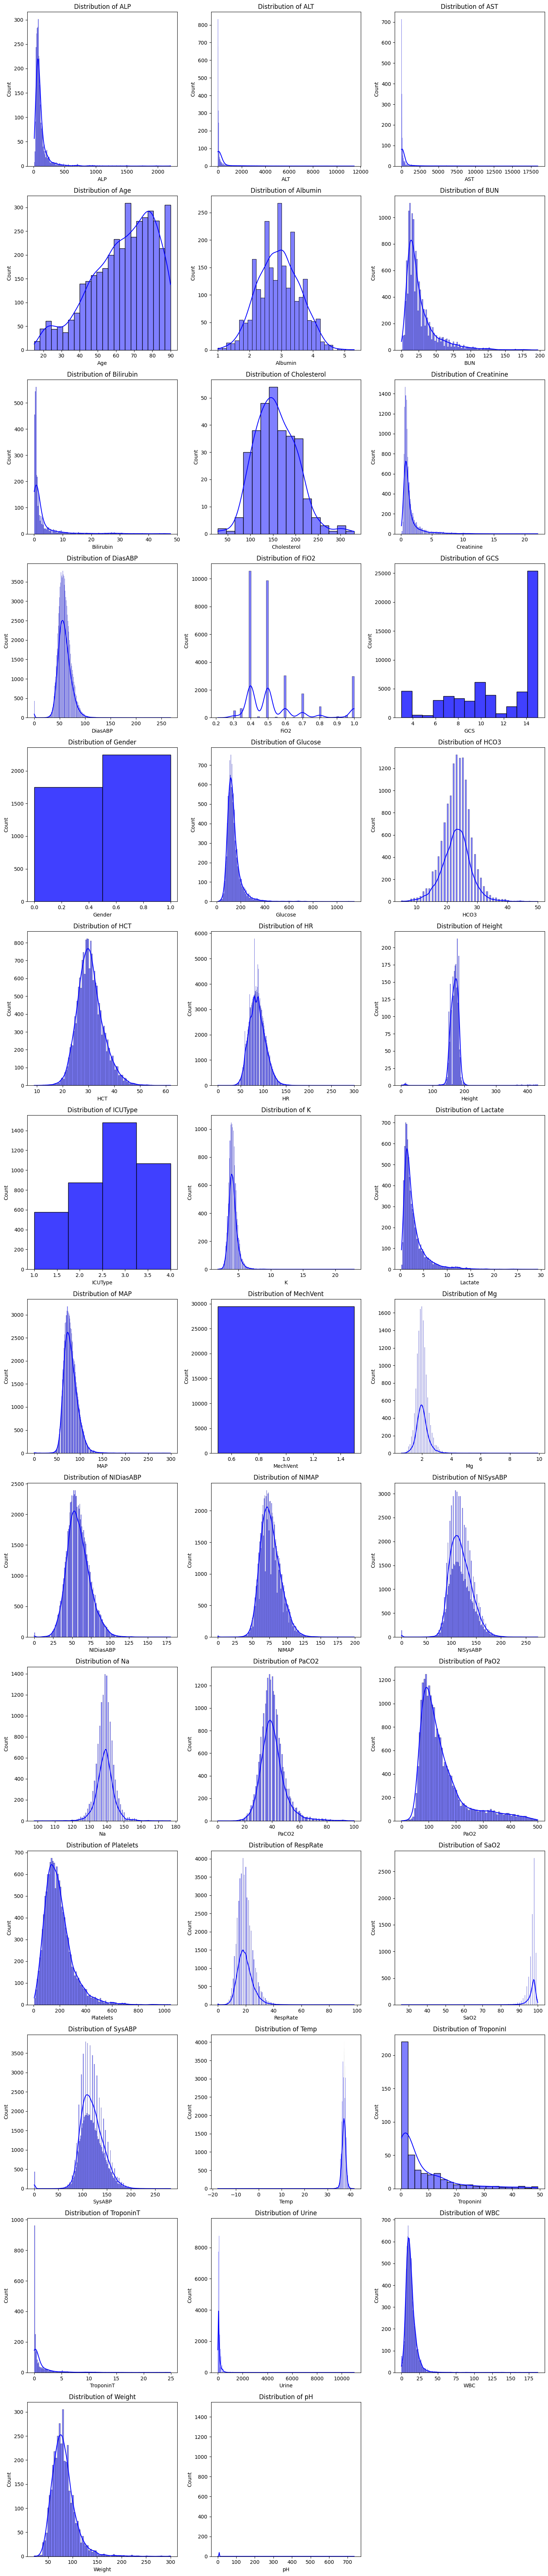

In [6]:
static_columns = ["Age", "Gender", "Height", "ICUType", "Weight"]

plot_distributions(X_set_a, static_columns)

In [7]:
X_set_a['MechVent'].value_counts()

MechVent
1.0    29480
Name: count, dtype: int64

In [8]:
pd.set_option('display.max_columns', None)
X_set_a.describe()

,recordid,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,Creatinine,DiasABP,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,Height,ICUType,K,Lactate,MAP,MechVent,Mg,NIDiasABP,NIMAP,NISysABP,Na,PaCO2,PaO2,Platelets,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
count,196000.00000,3086.000000,3171.000000,3176.000000,196000.000000,2353.000000,13889.000000,3186.000000,315.000000,13955.000000,103409.000000,30741.000000,61070.000000,195853.000000,12991.000000,13583.000000,18177.000000,172979.000000,103194.000000,196000.00000,14407.000000,7833.000000,102841.000000,29480.0,13571.000000,80812.000000,79795.000000,80905.000000,13539.000000,22414.000000,22396.000000,14022.000000,45886.000000,7885.000000,103421.000000,71228.000000,435.000000,2122.000000,132885.000000,12853.000000,181496.000000,23439.000000
mean,137605.12200,116.746273,394.886471,505.541562,64.247500,2.922822,27.410858,2.906497,156.517460,1.505131,59.541229,0.540513,11.407827,0.561921,141.384882,23.119532,30.691429,86.724497,169.787227,2.76000,4.135170,2.880011,80.202721,1.0,2.027677,58.135413,77.087944,119.153439,139.070980,40.397354,147.480419,191.062609,19.646973,96.662575,119.607120,37.077286,7.151264,1.200569,115.779518,12.670909,82.459773,7.490983
std,2923.25087,133.976599,1201.222503,1515.605791,17.558796,0.651804,23.402503,5.902983,46.068097,1.636898,13.008356,0.186372,3.967653,0.496152,67.282744,4.708806,5.003485,17.792949,20.169911,1.00245,0.704562,2.528529,16.241218,0.0,0.421997,15.058079,14.862425,21.988531,5.178215,9.065069,85.994352,106.514530,5.507075,3.296521,23.719396,1.523763,9.767399,2.716526,168.036664,7.649903,24.001268,8.384564
min,132539.00000,12.000000,1.000000,4.000000,15.000000,1.000000,0.000000,0.100000,28.000000,0.100000,0.000000,0.210000,3.000000,0.000000,10.000000,5.000000,9.000000,0.000000,1.800000,1.00000,1.800000,0.300000,0.000000,1.0,0.600000,0.000000,0.000000,0.000000,98.000000,0.300000,0.000000,6.000000,0.000000,26.000000,0.000000,-17.800000,0.300000,0.010000,0.000000,0.100000,0.000000,1.000000
25%,135075.75000,59.000000,20.000000,31.000000,52.750000,2.500000,13.000000,0.500000,123.000000,0.700000,51.000000,0.400000,8.000000,0.000000,105.000000,20.000000,27.400000,74.000000,162.600000,2.00000,3.700000,1.400000,69.000000,1.0,1.800000,48.000000,66.670000,103.000000,136.000000,35.000000,90.000000,119.000000,16.000000,96.000000,104.000000,36.600000,0.900000,0.060000,35.000000,8.300000,66.400000,7.330000
50%,137592.50000,82.000000,43.000000,64.000000,67.000000,2.900000,20.000000,0.900000,152.000000,1.000000,58.000000,0.500000,13.000000,1.000000,127.000000,23.000000,30.300000,86.000000,170.200000,3.00000,4.100000,2.000000,78.000000,1.0,2.000000,57.000000,75.330000,117.000000,139.000000,39.000000,120.000000,173.000000,19.000000,97.000000,117.000000,37.200000,2.600000,0.200000,70.000000,11.400000,80.000000,7.380000
75%,140100.25000,122.000000,162.000000,209.000000,78.000000,3.400000,33.000000,2.300000,188.000000,1.500000,67.000000,0.600000,15.000000,1.000000,157.000000,26.000000,33.600000,98.000000,177.800000,4.00000,4.500000,3.400000,89.000000,1.0,2.200000,67.000000,86.000000,133.000000,142.000000,45.000000,172.000000,238.000000,23.000000,98.000000,134.000000,37.700000,10.000000,1.020000,140.000000,15.400000,94.000000,7.430000
max,142673.00000,2205.000000,11470.000000,18430.000000,90.000000,5.300000,197.000000,47.700000,330.000000,22.100000,268.000000,1.000000,15.000000,1.000000,1143.000000,50.000000,61.800000,300.000000,431.800000,4.00000,22.900000,29.300000,299.000000,1.0,9.900000,180.000000,199.000000,274.000000,177.000000,100.000000,500.000000,1047.000000,98.000000,100.000000,282.000000,41.600000,49.200000,24.910000,11000.000000,187.500000,300.000000,735.000000


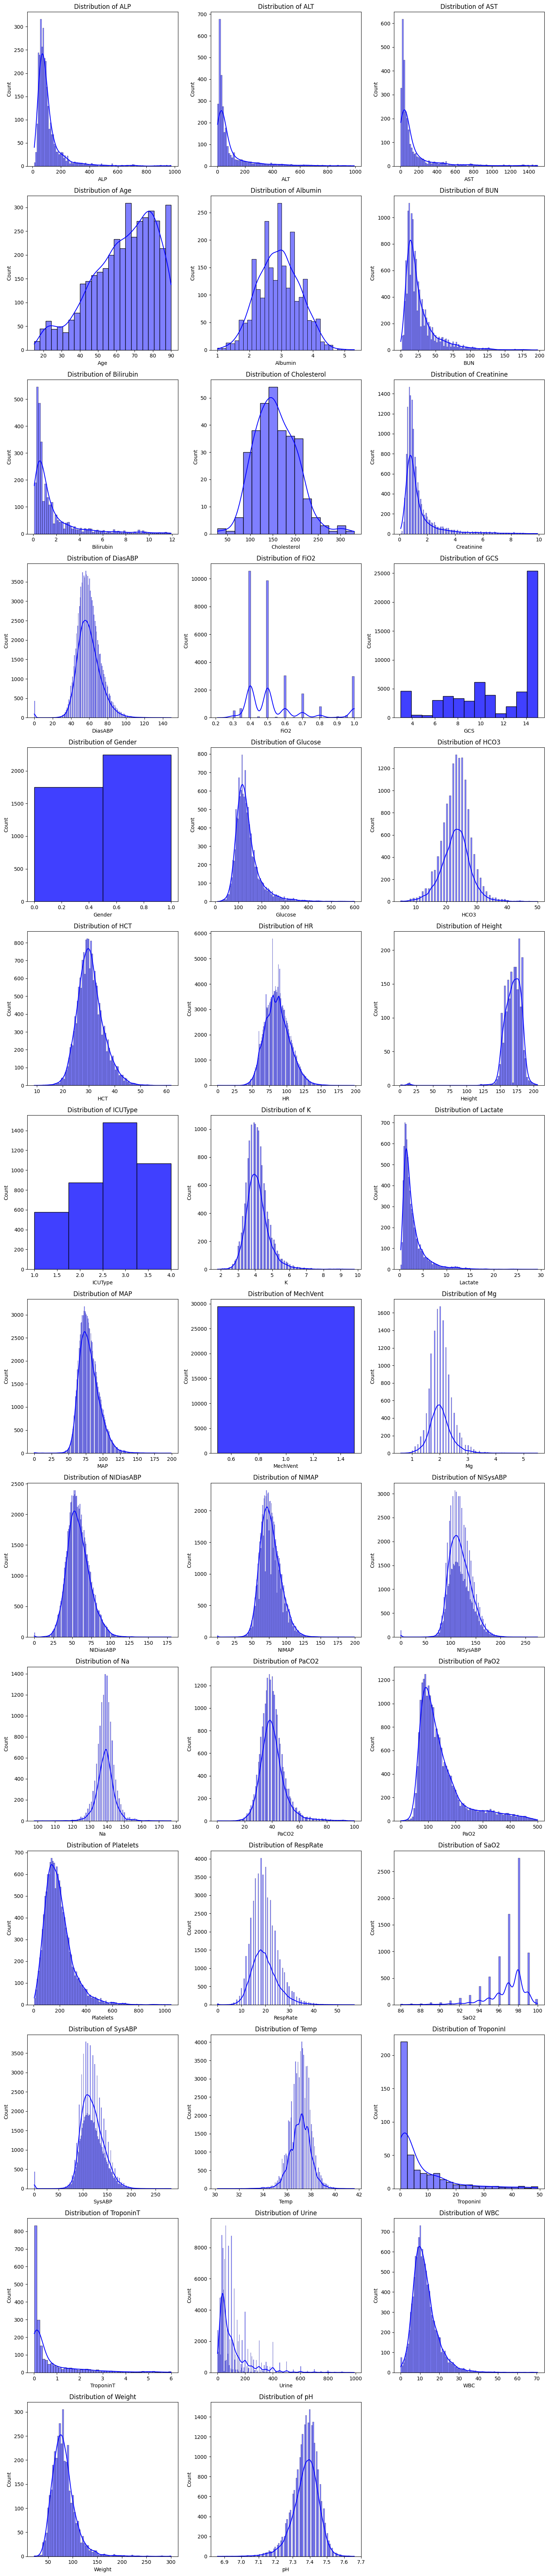

In [9]:
# Temporarily crop some outlier values to make the plot more readable
# Note: Ouliers will be removed in the preprocessing step, this is just for visualization
X_set_a_temp = X_set_a.copy()
X_set_a_temp.loc[X_set_a_temp['ALP'] >= 1000, 'ALP'] = np.nan
X_set_a_temp.loc[X_set_a_temp['ALT'] >= 1000, 'ALT'] = np.nan
X_set_a_temp.loc[X_set_a_temp['AST'] >= 1500, 'AST'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Bilirubin'] >= 12, 'Bilirubin'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Creatinine'] >= 10, 'Creatinine'] = np.nan
X_set_a_temp.loc[X_set_a_temp['DiasABP'] >= 150, 'DiasABP'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Glucose'] >= 600, 'Glucose'] = np.nan
X_set_a_temp.loc[X_set_a_temp['HR'] >= 200, 'HR'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Height'] >= 300, 'Height'] = np.nan
X_set_a_temp.loc[X_set_a_temp['K'] >= 10, 'K'] = np.nan
X_set_a_temp.loc[X_set_a_temp['MAP'] >= 200, 'MAP'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Mg'] >= 6, 'Mg'] = np.nan
X_set_a_temp.loc[X_set_a_temp['RespRate'] >= 60, 'RespRate'] = np.nan
X_set_a_temp.loc[X_set_a_temp['SaO2'] <= 85, 'SaO2'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Temp'] <= 30, 'Temp'] = np.nan
X_set_a_temp.loc[X_set_a_temp['TroponinT'] >= 6, 'TroponinT'] = np.nan
X_set_a_temp.loc[X_set_a_temp['Urine'] >= 1000, 'Urine'] = np.nan
X_set_a_temp.loc[X_set_a_temp['WBC'] >= 75, 'WBC'] = np.nan
X_set_a_temp.loc[X_set_a_temp['pH'] >= 15, 'pH'] = np.nan
X_set_a_temp.loc[X_set_a_temp['pH'] <= 5, 'pH'] = np.nan

plot_distributions(X_set_a_temp, static_columns)

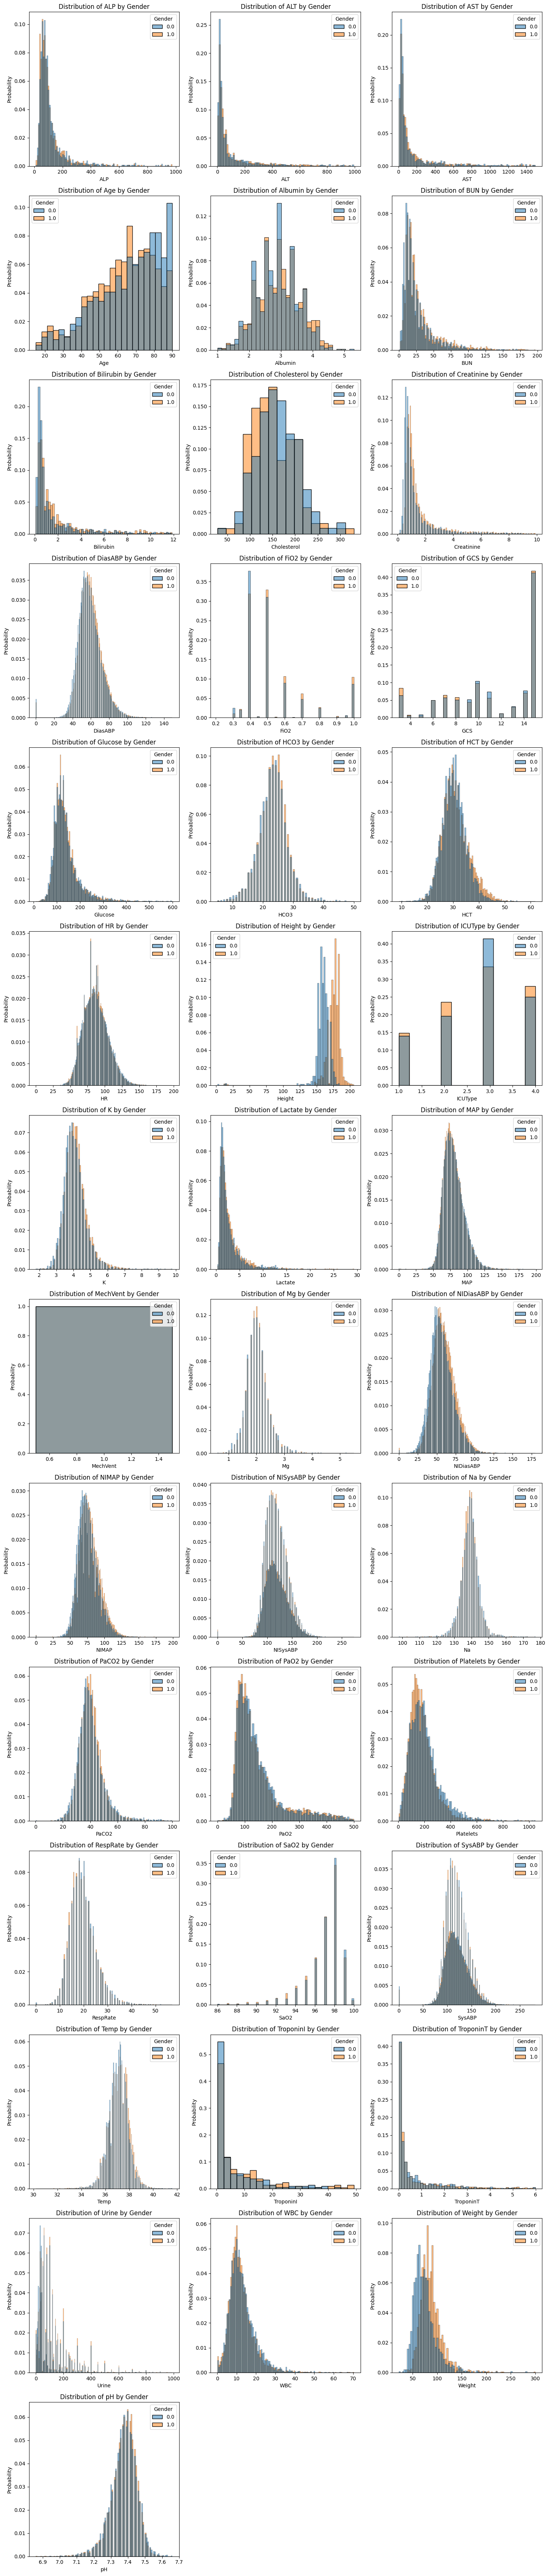

In [10]:
plot_distributions_by_gender(X_set_a_temp, static_columns)

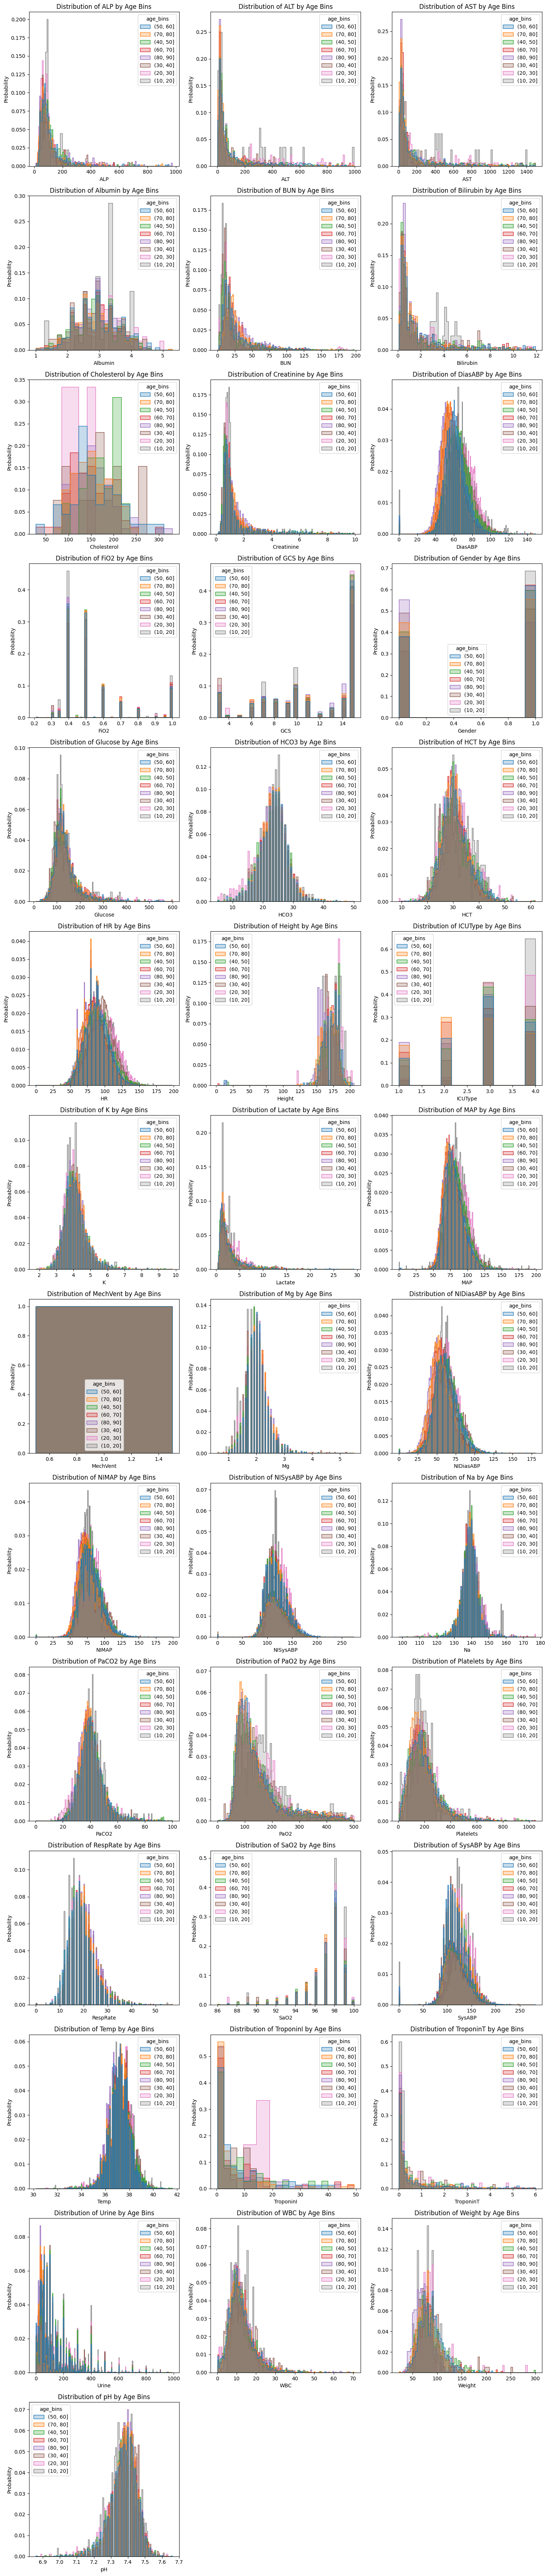

In [11]:
plot_distributions_by_age_bins(X_set_a_temp, static_columns)

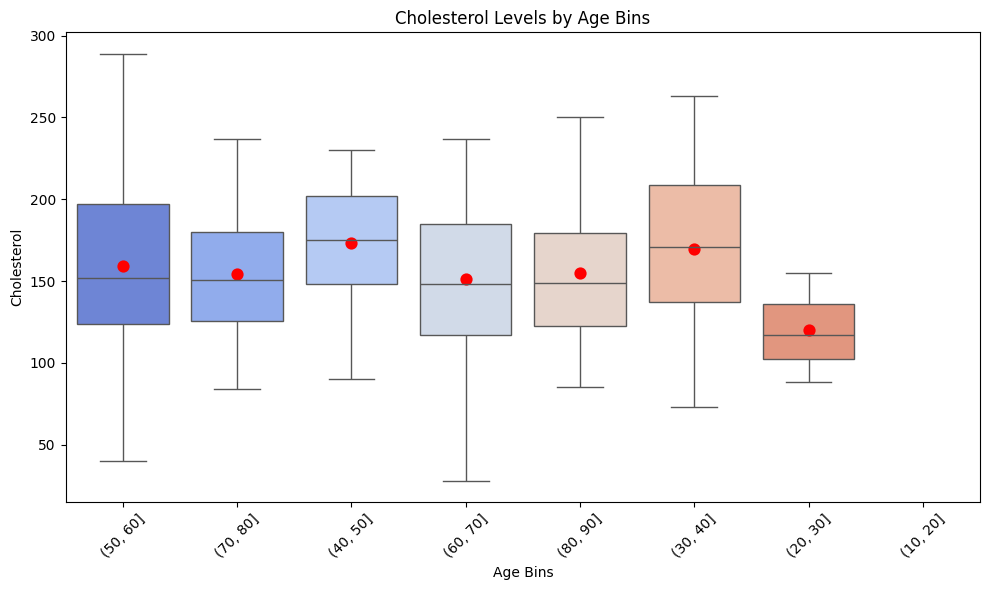

In [12]:
plot_cholesterol_by_age_bins(X_set_a)

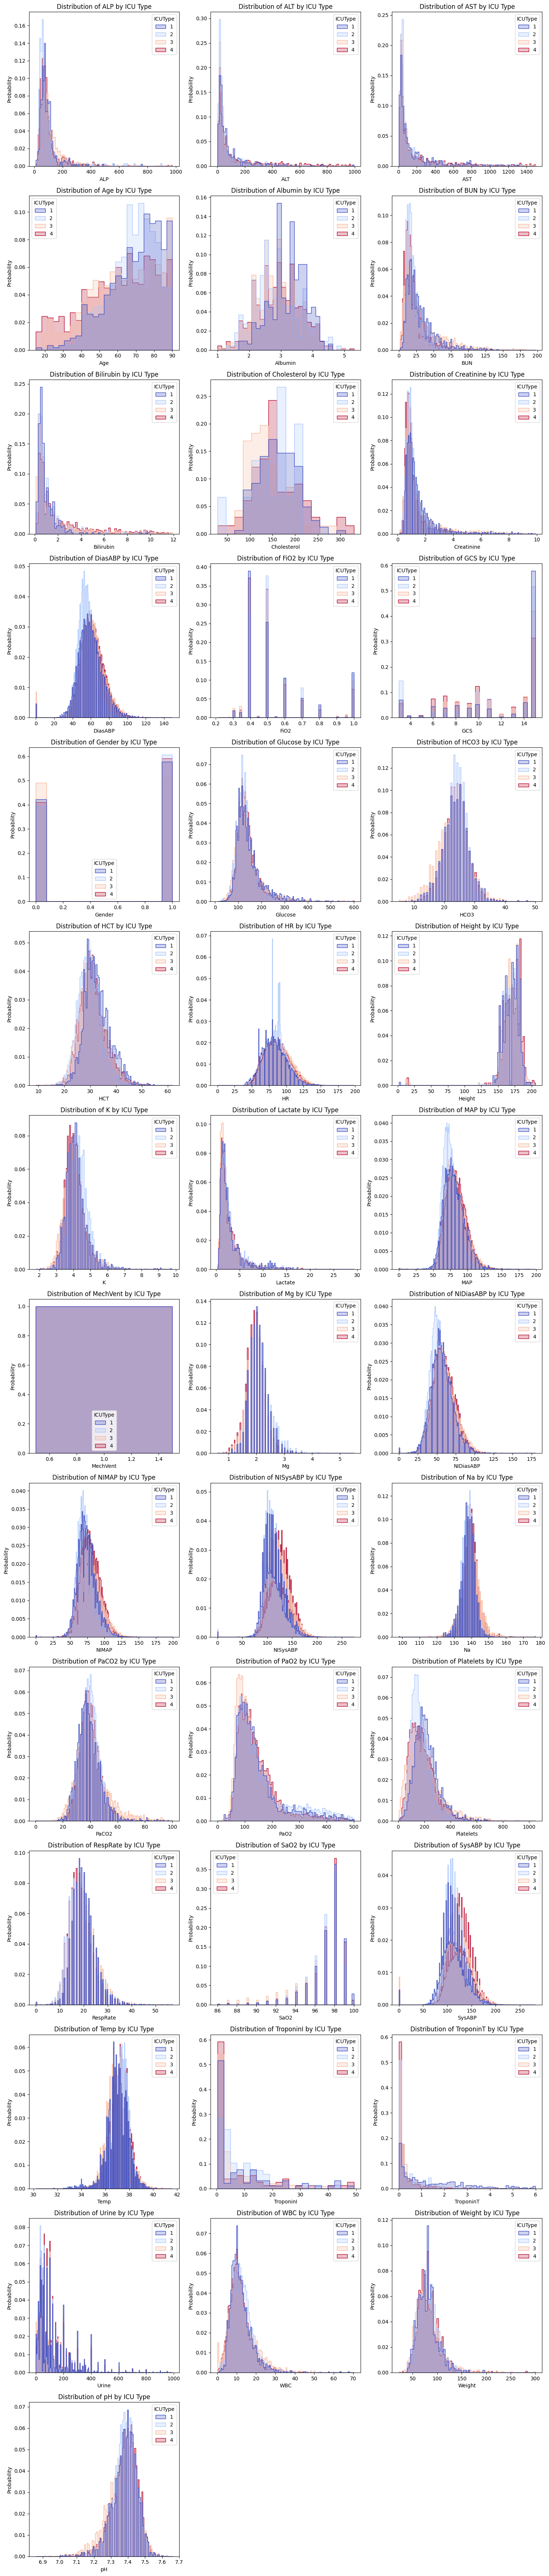

In [13]:
plot_distributions_by_icu_type(X_set_a_temp, static_columns)

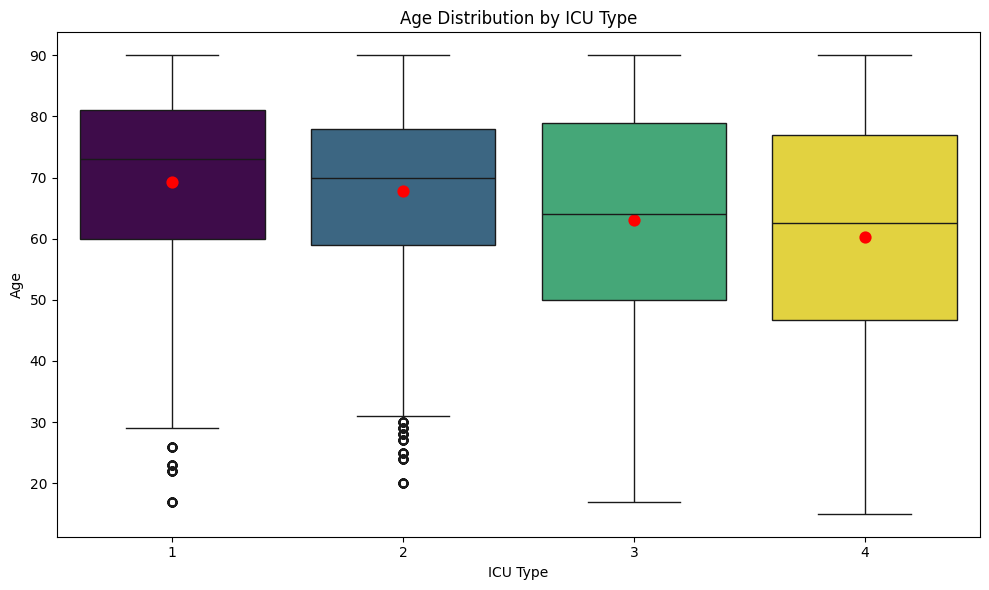

In [14]:
plot_age_distribution_by_icu_type(X_set_a)

#### Q1.3 Preprocess data for Machine Learning (2 Pts)

In [15]:
X_set_a = clean_data(X_set_a)
X_set_b = clean_data(X_set_b)
X_set_c = clean_data(X_set_c)

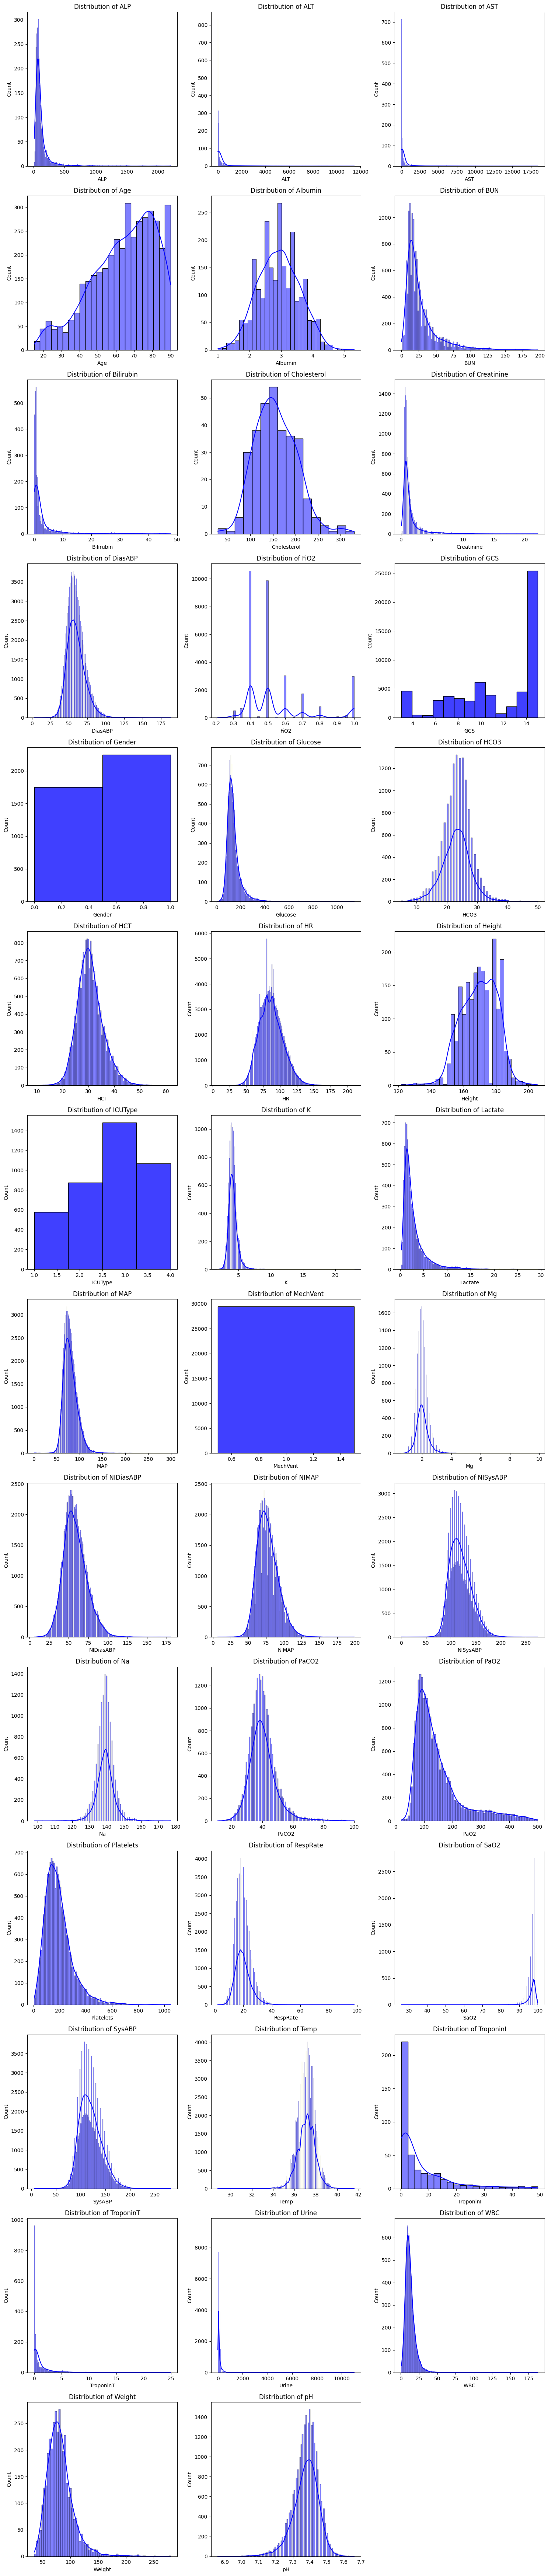

In [16]:
# Plot each column's distribution after cleaning
plot_distributions(X_set_a, static_columns)

#### Q2.3a: Transformers

In [25]:
def preprocess_data_for_transformer(df):
    # Make a copy to avoid modifying the original DataFrame
    df_processed = df.copy()
    
    # Identify feature columns (exclude recordid, time, and ICUType)
    exclude_cols = ['recordid', 'time', 'ICUType']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    # Group by patient (recordid) since we want to forward fill within each patient's time series
    grouped = df_processed.groupby('recordid')
    
    # Forward fill within each patient's time series
    df_processed[feature_cols] = grouped[feature_cols].ffill()
    
    # For any remaining NAs (e.g., first measurements that were NA), fill with median
    # Calculate medians from training data only to avoid data leakage
    train_medians = df_processed[feature_cols].median()
    df_processed[feature_cols] = df_processed[feature_cols].fillna(train_medians)
    
    return df_processed

# Apply preprocessing to each dataset
df_train_processed = preprocess_data_for_transformer(X_set_a)
df_val_processed = preprocess_data_for_transformer(X_set_b)
df_test_processed = preprocess_data_for_transformer(X_set_c)

In [26]:
# Data Preparation
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Assuming you have:
# - df_train (pandas DataFrame with columns: recordid, time, 41 features)
# - outcomes (pandas DataFrame with columns: recordid, In-hospital_death)

# 1. Process the DataFrame into proper 3D array (patients × timesteps × features)
def prepare_data_for_transformer(df, outcomes):
    # Get unique patient IDs
    patient_ids = df['recordid'].unique()
    
    # Initialize empty array (num_patients, 49 timesteps, 41 features)
    X = np.zeros((len(patient_ids), 49, 41))
    y = np.zeros(len(patient_ids))
    
    # Sort by recordid and time to ensure correct ordering
    df = df.sort_values(['recordid', 'time'])
    
    for i, pid in enumerate(patient_ids):
        # Get all measurements for this patient
        patient_data = df[df['recordid'] == pid]
        
        # Extract features (drop recordid and time columns)
        patient_features = patient_data.drop(['recordid', 'time'], axis=1).values
        
        # Ensure we have exactly 49 timesteps
        if len(patient_features) != 49:
            raise ValueError(f"Patient {pid} has {len(patient_features)} timesteps (expected 49)")
        
        X[i] = patient_features
        y[i] = outcomes.loc[outcomes['recordid'] == pid, 'in_hospital_death'].values[0]
    
    return X, y

# Prepare the data
X_train, y_train = prepare_data_for_transformer(df_train_processed, Y_set_a)
X_val, y_val = prepare_data_for_transformer(df_val_processed, Y_set_b)
X_test, y_test = prepare_data_for_transformer(df_test_processed, Y_set_c)

# Normalize the data (fit only on training set)
scaler = RobustScaler()
# Reshape to (num_samples*49, 41) for scaling
X_train_reshaped = X_train.reshape(-1, 41)
scaler.fit(X_train_reshaped)

# Scale all sets
X_train = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val_reshaped = X_val.reshape(-1, 41)
X_val = scaler.transform(X_val_reshaped).reshape(X_val.shape)
X_test_reshaped = X_test.reshape(-1, 41)
X_test = scaler.transform(X_test_reshaped).reshape(X_test.shape)

In [27]:
# PyTorch Dataset and Transformer Implementation
class ICUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = ICUDataset(X_train, y_train)
val_dataset = ICUDataset(X_val, y_val)
test_dataset = ICUDataset(X_test, y_test)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

import math
import torch.nn as nn
import torch.nn.functional as F

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=49):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ICUTransformer(nn.Module):
    def __init__(self, input_dim=41, d_model=64, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        
        # Input embedding
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x shape: (batch_size, seq_len=49, input_dim=41)
        x = self.input_proj(x)  # (batch_size, 49, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        
        # Use mean pooling across time dimension
        x = x.mean(dim=1)  # (batch_size, d_model)
        return self.classifier(x)

In [28]:
# Training and Evaluation
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        val_loss, val_auroc, val_auprc = evaluate_model(model, val_loader)
        
        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val AUROC: {val_auroc:.4f} | Val AUPRC: {val_auprc:.4f}")
        
    #     # Save best model
    #     if val_loss < best_val_loss:
    #         best_val_loss = val_loss
    #         torch.save(model.state_dict(), 'best_transformer_model.pth')
    
    # # Load best model
    # model.load_state_dict(torch.load('best_transformer_model.pth'))
    return model

def evaluate_model(model, loader):
    model.eval()
    criterion = nn.BCELoss()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)
    
    return total_loss/len(loader), auroc, auprc

# Initialize and train model
model = ICUTransformer()
model = train_model(model, train_loader, val_loader, epochs=10)

# Final evaluation on test set
test_loss, test_auroc, test_auprc = evaluate_model(model, test_loader)
print(f"\nTest Performance:")
print(f"Loss: {test_loss:.4f} | AUROC: {test_auroc:.4f} | AUPRC: {test_auprc:.4f}")

Epoch 1/10:
  Train Loss: 0.4091
  Val Loss: 0.3983 | Val AUROC: 0.6936 | Val AUPRC: 0.2547
Epoch 2/10:
  Train Loss: 0.3783
  Val Loss: 0.3586 | Val AUROC: 0.7584 | Val AUPRC: 0.3075
Epoch 3/10:
  Train Loss: 0.3517
  Val Loss: 0.3570 | Val AUROC: 0.7741 | Val AUPRC: 0.3258
Epoch 4/10:
  Train Loss: 0.3379
  Val Loss: 0.3396 | Val AUROC: 0.8023 | Val AUPRC: 0.3982
Epoch 5/10:
  Train Loss: 0.3284
  Val Loss: 0.3395 | Val AUROC: 0.7944 | Val AUPRC: 0.3571
Epoch 6/10:
  Train Loss: 0.3208
  Val Loss: 0.3260 | Val AUROC: 0.8209 | Val AUPRC: 0.4126
Epoch 7/10:
  Train Loss: 0.3124
  Val Loss: 0.3257 | Val AUROC: 0.8178 | Val AUPRC: 0.4139
Epoch 8/10:
  Train Loss: 0.3102
  Val Loss: 0.3585 | Val AUROC: 0.8058 | Val AUPRC: 0.4034
Epoch 9/10:
  Train Loss: 0.3060
  Val Loss: 0.3360 | Val AUROC: 0.8146 | Val AUPRC: 0.4152
Epoch 10/10:
  Train Loss: 0.2966
  Val Loss: 0.3342 | Val AUROC: 0.8133 | Val AUPRC: 0.4133

Test Performance:
Loss: 0.3476 | AUROC: 0.8016 | AUPRC: 0.3982
